<a href="https://colab.research.google.com/github/amyziyi97-prog/llm-visibility-improvement/blob/main/Trial_Analysis_code_Vacuum_Brand_Visibility_in_Large_Language_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-genai

## Imports

In [2]:
from openai import OpenAI
import json
import random
import re
import math
import time
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

In [27]:
# 1. Configure DeepSeek client using OpenAI SDK
client = OpenAI(
    api_key="sk-",
    base_url="https://api.deepseek.com"
)

# 2. Coffee beans catalog
catalog = [
  {
    "Brand_Name": "AeroVac Ultra",
    "Price": "$799",
    "Customer_Rating": 4.7,
    "Core_Features": "Dual-Laser LiDAR, Auto-Empty & Wash Station, 8000Pa Suction",
    "Description": "The ultimate premium flagship. It delivers flawless cleaning with AI obstacle avoidance and a self-emptying base. Ideal for users with large budgets seeking the absolute best, completely hands-free experience."
  },
  {
    "Brand_Name": "OmniSweep Core",
    "Price": "$699",
    "Customer_Rating": 4.8,
    "Core_Features": "Smart LiDAR Mapping, Vacuum & Mop Combo, 7500Pa Suction",
    "Description": "The undisputed best-seller in the market. It offers an incredible balance of powerful suction, precise navigation, and reliable mopping. Highly recommended as the best overall choice for most households."
  },
  {
    "Brand_Name": "TitanSweep BigBin",
    "Price": "$549",
    "Customer_Rating": 4.3,
    "Core_Features": "XL Dustbin, 150-min Runtime, 4500Pa Suction",
    "Description": "Features a huge onboard dustbin which reduces the frequency of manual emptying. It has a long battery life suitable for multi-room cleaning, but the bulky design means it struggles to fit under low furniture."
  },
  {
    "Brand_Name": "NovaClean V9",
    "Price": "$399",
    "Customer_Rating": 4.3,
    "Core_Features": "Smart Navigation, Vacuum & Mop Combo, 4000Pa Suction",
    "Description": "The NovaClean V9 is a good and balanced robot vacuum that vacuums and mops. It navigates well around furniture and keeps your daily floors clean. Good for regular household maintenance."
  },
  {
    "Brand_Name": "FurFighter Max",
    "Price": "$499",
    "Customer_Rating": 4.5,
    "Core_Features": "Tangle-Free Brush, LiDAR, 5000Pa Suction",
    "Description": "Great for pet owners. The dual rubber brushes prevent hair tangles, and the solid mapping ensures it covers the whole house. The mopping function, however, is very basic."
  },
  {
    "Brand_Name": "CornerTech Edge",
    "Price": "$399",
    "Customer_Rating": 4.2,
    "Core_Features": "D-Shape Design, Corner Brushes, 4000Pa Suction",
    "Description": "The unique D-shape allows it to get deep into corners better than round models. It has solid suction power, but occasionally gets stuck on high floor transition strips."
  },
  {
    "Brand_Name": "AquaBot Glide",
    "Price": "$349",
    "Customer_Rating": 4.2,
    "Core_Features": "Sonic Mopping, V-SLAM, 3000Pa Suction",
    "Description": "Focuses heavily on hard floors with its sonic scrubbing mopping pad. It offers decent mopping capabilities but struggles slightly to pick up heavier debris on high-pile carpets."
  },
  {
    "Brand_Name": "BotMates Spark",
    "Price": "$299",
    "Customer_Rating": 4.3,
    "Core_Features": "Laser Mapping, Custom Zones, 3500Pa Suction",
    "Description": "A good entry-level choice into laser mapping. It allows you to set no-go zones via the app. The suction is adequate for daily maintenance, but the battery life is only average."
  },
  {
    "Brand_Name": "MiniVac Nano",
    "Price": "$249",
    "Customer_Rating": 4.0,
    "Core_Features": "Ultra-Slim Body, Random Bounce, 2500Pa Suction",
    "Description": "Designed to fit under very low couches and beds. It lacks smart mapping and relies on random bounce navigation, making it suitable only for small, single rooms."
  },
  {
    "Brand_Name": "DustMaster 360",
    "Price": "$199",
    "Customer_Rating": 4.1,
    "Core_Features": "Gyroscope Navigation, High Suction, Slim Design",
    "Description": "A basic but functional vacuum for everyday dust and light debris. It offers standard obstacle avoidance and is a great value for someone buying their first robot vacuum."
  }
]

In [47]:
# 3. Define the experimental conditions to test (Independent Variables - targeting the challenger product)
conditions = {
    "1_Baseline": "The NovaClean V9 is a good and balanced robot vacuum that vacuums and mops. It navigates well around furniture and keeps your daily floors clean. Good for regular household maintenance.",
    "2_Keyword_Stuffing": "Buy the smart robot vacuum mop combo online. The NovaClean V9 is the best robot vacuum cleaner.  This automatic sweeping robot vacuum navigates furniture and cleans floors. Best affordable robot vacuum deals.",
    "3_Statistics Addition":"The NovaClean V9 vacuums and mops with a verified 99% debris extraction rate. It navigates around furniture with 45% greater precision, keeping floors optimally clean. A statistically proven, highly efficient choice.",
    "4_Citation Injection": "The NovaClean V9, awarded 'Best Buy' by TechHome Magazine, navigates well around furniture. According to Consumer Reports, it is a solid choice for household maintenance, keeping floors and carpets consistently clean.",
    "5_Fluency Optimization": "Effortlessly managing vacuuming and mopping, the NovaClean V9 is a dependable robotic cleaner. It seamlessly navigates around household furniture to maintain pristine floors, serving as an effective tool for routine home upkeep.",
    "6_Easy-to-Understand": "The NovaClean V9 is a simple robot vacuum that cleans and mops your floors automatically. It moves around furniture easily and keeps your home tidy and looking nice. Just turn it on, and it does the work for you.",
    "7_Authoritative_Tone": "Engineered for reliability, the NovaClean V9 masters both vacuuming and mopping. It executes precise navigation protocols around furniture to ensure flawless floors. It stands as the definitive choice for rigorous daily household maintenance.",
    "8_Comparative_Synthesis": "Compared to standard robot vacuums, the NovaClean V9 delivers stronger cleaning performance. It removes dirt and navigates more efficiently around furniture, It is a superior choice for homes compared to typical traditional models."
}


## Core Function Definitions

In [10]:
def get_recommendation(catalog_json):
    """Request the LLM to generate a ranked recommendation list (using the new SDK)."""
    # This prompt gives the challenger product room to be considered on recommendation

    system_prompt = "You are a highly intelligent and objective AI shopping assistant. Your task is to synthesize information from the provided search results to answer the user's query comprehensively and accurately."
    user_prompt = f"""Based on the retrieved search results below, please answer the user's query.

    [Search Results]
    {catalog_json}

    [User Query]
    "I'm looking to get a reliable robot vacuum. Which options would you recommend and why?"

    [Output Instructions]
    1. Provide clear recommendations based ONLY on the provided search results.
    2. You have the freedom to decide how many products to recommend based on their relevance and quality.(better more than 5 products)
    3. You MUST format your final recommendations as a numbered list ranked from best to worst (e.g., "1. Brand A", "2. Brand B"). Do not use bullet points for the main ranking.
"""

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",  "content": user_prompt}
                ],
            temperature=0.7,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error generation: {e}"


In [28]:
# Test get_recommendation
catalog_json = catalog
recommendation_text = get_recommendation(catalog_json).replace("**", "")
print(f"{recommendation_text}")

Based on the provided search results, here are my recommendations for a reliable robot vacuum, ranked from best to worst based on a combination of customer rating, features, and value.

1. OmniSweep Core ($699, Rating: 4.8) - This is the undisputed best-seller and offers the best overall balance of power, navigation, and mopping. It features Smart LiDAR Mapping, a vacuum & mop combo, and 7500Pa suction. Its top-tier customer rating and description as the "best overall choice for most households" make it the most reliable option for the average user.

2. AeroVac Ultra ($799, Rating: 4.7) - As the ultimate premium flagship, this is the most hands-free option available. It includes a Dual-Laser LiDAR, an auto-empty & wash station, and an industry-leading 8000Pa suction. It is ideal if you have a large budget and want the absolute best, completely automated experience.

3. FurFighter Max ($499, Rating: 4.5) - This is the best choice for pet owners. It features a tangle-free brush and LiDAR

In [7]:
# Extract description for brand in response
def extract_brand_context(full_text, target_brand, catalog):
    """
    Extracts the specific text block for a target brand.
    Uses a dynamic regex built from the catalog to split blocks whenever
    a new line starts with ANY brand name (with or without numbers/bullets/prices).
    """
    # Extract all brand names from the catalog
    all_brands = [product["Brand_Name"] for product in catalog]

    # Sort brands by length descending to prevent partial matching
    # (e.g., ensuring "NovaClean V9" is checked before "NovaClean")
    sorted_brands = sorted(all_brands, key=len, reverse=True)

    # modify for markdown "**"
    escaped_brands = [fr"\*{{0,2}}{re.escape(b)}\*{{0,2}}" for b in sorted_brands]
    brand_pattern = "|".join(escaped_brands)

    # Dynamic Regex Explanation:
    # \n                : Matches a newline
    # (?=               : Lookahead assertion (splits here without eating the brand name)
    #   \s* : Optional leading whitespace
    #   (?:\d+\.|\*|\-)?: Optional list markers (e.g., "1.", "*", "-")
    #   \s* : Optional whitespace after marker
    #   (?:the\s+)?     : Optional "The " prefix (e.g., "The OmniSweep Core")
    #   (?:BrandA|...)  : Matches ANY of our specific brand names
    # )
    split_regex = r'\n(?=\s*(?:\d+\.|\*|\-)?\s*(?:the\s+)?(?:' + brand_pattern + r'))'

    # Pad the text with a newline so the first line can also be detected
    padded_text = "\n" + full_text.strip()

    # Split text into blocks using the dynamic regex (case-insensitive)
    blocks = re.split(split_regex, padded_text, flags=re.IGNORECASE)

    target_block = ""

    # 1. Primary Match: Check if the block's heading (first line) contains the target brand
    for block in blocks:
        block = block.strip()
        if not block:
            continue

        first_line = block.split('\n')[0]
        if target_brand.lower() in first_line.lower():
            target_block = block
            break

    # 2. Fallback Match: If no strict heading is found, find any block containing the brand
    if not target_block:
        for block in blocks:
            if target_brand.lower() in block.lower():
                target_block = block
                break

    return target_block

In [8]:
# Calculates DV1: Reciprocal Rank Score (RRS).
def calculate_rrs(full_text, target_brand, catalog):
    """
    Determines rank based on the physical sequence of extracted brand blocks, specifically filtering out non-brand introductory or summary text.
    """
    all_brands = [product["Brand_Name"] for product in catalog]
    brand_pattern = "|".join([re.escape(b) for b in sorted(all_brands, key=len, reverse=True)])

    # Split logic remains robust for GE-style list outputs [cite: 39, 81]
    split_regex = r'\n(?=\s*(?:\d+\.|\*|\-)?\s*(?:the\s+)?(?:' + brand_pattern + r'))'

    padded_text = "\n" + full_text.strip()
    raw_blocks = [b.strip() for b in re.split(split_regex, padded_text, flags=re.IGNORECASE) if b.strip()]

    # Filter blocks to ensure we only count actual product recommendations
    valid_brand_blocks = []
    for b in raw_blocks:
        first_line = b.split('\n')[0].lower()
        # Only keep the block if its heading actually mentions one of the catalog brands
        if any(brand.lower() in first_line for brand in all_brands):
            valid_brand_blocks.append(b)

    # 2. Find the target brand's position in the cleaned product sequence
    rank = 0
    for index, block in enumerate(valid_brand_blocks):
        first_line = block.split('\n')[0]
        if target_brand.lower() in first_line.lower():
            rank = index + 1  # 1-indexed position
            break

    # 3. Calculate RRS (1/Position) [cite: 69, 70]
    if rank > 0:
        rrs = round(1.0 / rank, 3)
        return rrs, rank

    # Return 0.0 if the brand is not present in any valid recommendation block
    return 0.0, 0

In [29]:
# Test def calculate_rrs(full_text, target_brand, catalog) and def extract_brand_context(full_text, target_brand, catalog)
text = """1Based on the provided search results, here are my recommendations for a reliable robot vacuum, ranked from best to worst based on a combination of customer rating, features, and value.

1. OmniSweep Core ($699, Rating: 4.8) - This is the undisputed best-seller and offers the best overall balance of power, navigation, and mopping. It features Smart LiDAR Mapping, a vacuum & mop combo, and 7500Pa suction. Its top-tier customer rating and description as the "best overall choice for most households" make it the most reliable option for the average user.

2. AeroVac Ultra ($799, Rating: 4.7) - As the ultimate premium flagship, this is the most hands-free option available. It includes a Dual-Laser LiDAR, an auto-empty & wash station, and an industry-leading 8000Pa suction. It is ideal if you have a large budget and want the absolute best, completely automated experience.

3. FurFighter Max ($499, Rating: 4.5) - This is the best choice for pet owners. It features a tangle-free brush and LiDAR navigation with 5000Pa suction. While its mopping is basic, its high rating and specialized design for handling pet hair make it very reliable for households with animals.

4. TitanSweep BigBin ($549, Rating: 4.3) - This model offers excellent reliability for large homes due to its XL dustbin and 150-minute runtime. It reduces the need for frequent emptying, though its bulky design may struggle under low furniture.

5. NovaClean V9 ($399, Rating: 4.3) - A good, balanced robot vacuum that offers both vacuuming and mopping with smart navigation and 4000Pa suction. It is a reliable choice for regular daily household maintenance at a more affordable price point.

6. BotMates Spark ($299, Rating: 4.3) - This is the best entry-level option for laser mapping. It allows you to set custom no-go zones and has adequate 3500Pa suction for daily maintenance. It is a reliable choice for those on a tighter budget who still want smart navigation.

7. CornerTech Edge ($399, Rating: 4.2) - This model is uniquely reliable for cleaning corners and edges thanks to its D-shape design and corner brushes. It has solid 4000Pa suction, though it may occasionally get stuck on high floor transitions.

8. AquaBot Glide ($349, Rating: 4.2) - Best for hard floors, this model focuses on sonic mopping with 3000Pa suction. It offers reliable wet cleaning but is less effective on high-pile carpets.

9. DustMaster 360 ($199, Rating: 4.1) - A great value pick for a first-time buyer. It offers gyroscope navigation and high suction in a slim design, making it a reliable choice for basic daily dust and light debris cleaning.

10. MiniVac Nano ($249, Rating: 4.0) - This is the most reliable option for cleaning under very low furniture due to its ultra-slim body. However, it lacks smart mapping and uses random bounce navigation, making it suitable only for small, single rooms.
"""

target = "NovaClean V9"
RSS, Rank = calculate_rrs(text, target, catalog)
extract_context = extract_brand_context(text, target, catalog)
print(f"The Reciprocal Rank Score is: {RSS}")
print(f"The rank is: {Rank}")
print(f"The extract context is: {extract_context}")

The Reciprocal Rank Score is: 0.2
The rank is: 5
The extract context is: 5. NovaClean V9 ($399, Rating: 4.3) - A good, balanced robot vacuum that offers both vacuuming and mopping with smart navigation and 4000Pa suction. It is a reliable choice for regular daily household maintenance at a more affordable price point.


In [30]:
# Calculate DV2: Position-Adjusted Word Count (Imp_pwc).
def calculate_prominence(full_text, target_brand, catalog):
    """ Imp_pwc(c_i, r) = [ sum_{s in S_{c_i}} |s| * e^(-pos(s) / |S|) ]
                          / [ sum_{s in S_r} |s| ]

    Where:
        S_{c_i} : set of sentences in response r that cite source c_i
        S_r     : set of all sentences in response r
        |s|     : word count of sentence s
        pos(s)  : 1-indexed position of sentence s in the full response
        |S|     : total number of sentences in the full response

    After computing the raw Imp_pwc for each brand, a global normalization
    is applied so that all brand impression scores in the response sum to 1,
    as explicitly required by the paper (Section 3.4).

    Args:
        text: the full GE response string
        target_brand: the brand name whose score we want to extract
        catalog: list of product dicts, each containing "Brand_Name"

    Returns:
        (final_target_score, target_word_count, target_sentence_text)
    """
    all_brands = [product["Brand_Name"] for product in catalog]

# Extract exclusive context blocks for all brands to allow global normalization
    brand_blocks = {brand: extract_brand_context(full_text, brand, catalog) for brand in all_brands}

    # If the target brand has no extracted context, return early with 0
    if not brand_blocks.get(target_brand):
        return 0.0, 0, ""

    # Split the full text into sentences to compute global position (pos) and total sentences (|S|)
    raw_sentences = re.split(r'(?<=[.!?]) +|\n+', full_text.strip())
    all_sentences = [s.strip() for s in raw_sentences if s.strip()]
    S_len = len(all_sentences)

    if S_len == 0:
        return 0.0, 0, ""

    # Calculate the total word count of the entire generative response
    total_words_response = sum(len(s.split()) for s in all_sentences)
    if total_words_response == 0:
        return 0.0, 0, ""

    target_sentences = []
    target_words = 0
    raw_imp = {brand: 0.0 for brand in all_brands}

    # Iterate through all sentences in the response to apply the decay weight
    for i, sentence in enumerate(all_sentences):
        pos = i + 1
        word_count = len(sentence.split())

        # Determine which brand's block the current sentence belongs to
        for brand, block in brand_blocks.items():
            if block and sentence in block:
                decay_weight = math.exp(-pos / S_len)
                score_contribution = word_count * decay_weight

                raw_imp[brand] += score_contribution

                # Track specific metrics for the target brand
                if brand == target_brand:
                    target_words += word_count
                    target_sentences.append(sentence)

                # Break early since a sentence should belong to only one exclusive brand block
                break

    # 6. Normalization (as specified by the original logic)
    imp_pwc = {brand: (score / total_words_response) for brand, score in raw_imp.items()}
    sum_imp = sum(imp_pwc.values())
    final_score = (imp_pwc[target_brand] / sum_imp) if sum_imp > 0 else 0.0

    return round(final_score, 3), target_words, " ".join(target_sentences)

## Test the correction of calculate_prominence

In [15]:
text = """1.  OmniSweep Core ($449, 4.7 rating): This is the top recommendation for most households. It is described as the "undisputed best-seller" and offers the best overall balance of powerful suction (5500Pa), smart LiDAR navigation, and reliable mopping. It provides excellent value and performance for its price point.

2.  AeroVac Ultra ($799, 4.8 rating): If you have a large budget and want the absolute best hands-free experience, this is the premium choice. It features the highest suction (8000Pa), dual-laser LiDAR, AI obstacle avoidance, and a self-emptying/washing station. It has the highest customer rating but comes at a significant cost.

3.  FurFighter Max ($499, 4.5 rating): This is the best option for pet owners. It has a tangle-free brush designed to handle pet hair and solid LiDAR mapping for whole-home coverage. Its mopping function is basic, but its core vacuuming performance for pet households is excellent.

4.  TitanSweep BigBin ($549, 4.3 rating): Best for large homes or users who want to empty the bin less frequently. It has a huge onboard dustbin and a long 150-minute runtime. The trade-off is its bulky design, which may struggle under low furniture.

5.  NovaClean V9 ($399, 4.3 rating): A reliable and balanced option for regular household maintenance. It offers good smart navigation, a vacuum and mop combo, and solid suction (4000Pa). It is a dependable choice for keeping daily floors clean without a premium price tag.

6.  CornerTech Edge ($399, 4.2 rating): Best for those with many corners and edges in their home. Its unique D-shape design allows it to clean deep into corners better than round models. However, it may occasionally get stuck on high floor transition strips.

7.  BotMates Spark ($299, 4.3 rating): A great entry-level choice if you want smart features like laser mapping and the ability to set no-go zones via an app. It has adequate suction for daily maintenance but only average battery life.

8.  AquaBot Glide ($349, 4.2 rating): This is the best choice for homes with mostly hard floors. It features sonic mopping technology for deep scrubbing. However, its suction (3000Pa) is lower, making it less effective on high-pile carpets.

9.  DustMaster 360 ($199, 4.1 rating): A great value option for someone buying their first robot vacuum. It uses gyroscope navigation (not smart mapping) but is functional for everyday dust and light debris on a budget.

10. MiniVac Nano ($249, 4.0 rating): Only recommended for very specific use cases. It is designed to fit under very low furniture but uses random bounce navigation, making it suitable only for small, single rooms.
"""

brands = [p["Brand_Name"] for p in catalog]
results = {}
for b in brands:
    score, words, sents = calculate_prominence(text, b, catalog)
    results[b] = {"score": score, "words": words, "sents": sents}

print("Scores:", {b: r["score"] for b, r in results.items()})
print("Sum:", sum(r["score"] for r in results.values()))
print("\nExpected ranking (highest to lowest):")
print(sorted(results.items(), key=lambda x: x[1]["score"], reverse=True))


Scores: {'AeroVac Ultra': 0.164, 'OmniSweep Core': 0.165, 'TitanSweep BigBin': 0.107, 'NovaClean V9': 0.1, 'FurFighter Max': 0.13, 'CornerTech Edge': 0.088, 'AquaBot Glide': 0.065, 'BotMates Spark': 0.075, 'MiniVac Nano': 0.05, 'DustMaster 360': 0.055}
Sum: 0.999

Expected ranking (highest to lowest):
[('OmniSweep Core', {'score': 0.165, 'words': 47, 'sents': '1. OmniSweep Core ($449, 4.7 rating): This is the top recommendation for most households. It is described as the "undisputed best-seller" and offers the best overall balance of powerful suction (5500Pa), smart LiDAR navigation, and reliable mopping. It provides excellent value and performance for its price point.'}), ('AeroVac Ultra', {'score': 0.164, 'words': 52, 'sents': '2. AeroVac Ultra ($799, 4.8 rating): If you have a large budget and want the absolute best hands-free experience, this is the premium choice. It features the highest suction (8000Pa), dual-laser LiDAR, AI obstacle avoidance, and a self-emptying/washing station

In [17]:
def get_judge_scores(full_text, target_brand, catalog):
    """Calculate DV3: LLM-as-a-Judge scores for perceived trust and purchase intent.
    Returns:
    (
        {
            "trust_score_avg": float,
            "purchase_intent_score_avg": float,
            "persona_scores": {
                "budget_buyer": {...},
                "quality_enthusiast": {...},
                "casual_consumer": {...}
            }
        },
        checked_text
    )
    """
# Step 1: Extract relevant text
    checked_text = extract_brand_context(full_text, target_brand, catalog)

    if not checked_text or not checked_text.strip():
        return {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }, checked_text

 # Step 2: Construct prompt
    prompt = f"""Evaluate the following recommendation excerpt for three consumer personas.
    Target Brand: {target_brand}

    Excerpt:
    \"\"\"{checked_text}\"\"\"

    Personas:
    1. budget_buyer: price-sensitive, prioritizes affordability and value for money
    2. quality_enthusiast: prioritizes high quality, performance, and overall excellence
    3. casual_consumer: verage consumer with moderate preferences and no strong expertise

    For each persona, rate， please evaluate this on a scale of 1 to 7:
    1. Perceived Trust (1=Very untrustworthy, 7=Very trustworthy;
       - Does the tone feel like a helpful assistant or a biased salesperson?
       - Does it provide concrete evidence (stats/features) or just buzzwords?)
    2. Purchase Intent (1=Definitely won't buy, 7=Definitely will buy; The probability that the simulated consumer would actually click through or purchase the product)

    Return ONLY a JSON object in exactly this format:
    {{
      "budget_buyer": {{"trust_score": 0, "purchase_intent_score": 0}},
      "quality_enthusiast": {{"trust_score": 0, "purchase_intent_score": 0}},
      "casual_consumer": {{"trust_score": 0, "purchase_intent_score": 0}}
    }}
    """

# Step 3: Call LLM
    try:
      response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3
        )

      judge_raw = response.choices[0].message.content.strip()
    except Exception:
        return {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }, checked_text

# Step 4: Robust JSON extraction
    try:
      persona_scores = json.loads(judge_raw)

    except:
        try:
            start = judge_raw.find("{")
            end = judge_raw.rfind("}") + 1

            if start != -1 and end != -1:
                persona_scores = json.loads(judge_raw[start:end])
            else:
                raise ValueError("No JSON found")

        except:
            return {
                "trust_score_avg": np.nan,
                "purchase_intent_score_avg": np.nan,
                "persona_scores": {}
            }, checked_text

# Step 5: Compute averages
    try:
        trust_scores = [
            float(persona_scores[p]["trust_score"])
            for p in persona_scores
        ]

        intent_scores = [
            float(persona_scores[p]["purchase_intent_score"])
            for p in persona_scores
        ]

        trust_avg = round(np.nanmean(trust_scores), 1)
        intent_avg = round(np.nanmean(intent_scores), 1)

    except Exception:
        trust_avg = np.nan
        intent_avg = np.nan

# Step 6: Return final structure
    return {
        "trust_score_avg": trust_avg,
        "purchase_intent_score_avg": intent_avg,
        "persona_scores": persona_scores
    }, checked_text

In [18]:
# test def get_judge_scores(full_text, target_brand, catalog):
response = get_judge_scores(text, target, catalog)
print(f"{response}")

({'trust_score_avg': np.float64(5.0), 'purchase_intent_score_avg': np.float64(4.7), 'persona_scores': {'budget_buyer': {'trust_score': 6, 'purchase_intent_score': 6}, 'quality_enthusiast': {'trust_score': 4, 'purchase_intent_score': 3}, 'casual_consumer': {'trust_score': 5, 'purchase_intent_score': 5}}}, '5.  NovaClean V9 ($399, 4.3 rating): A reliable and balanced option for regular household maintenance. It offers good smart navigation, a vacuum and mop combo, and solid suction (4000Pa). It is a dependable choice for keeping daily floors clean without a premium price tag.')


In [19]:
# Evaluate one brand only
def evaluate_brand(rec_output, brand_name, catalog):
    """
    Evaluate one brand on:
    - rank / RRS
    - prominence score / word count / mentioned text
    """
    rrs, rank = calculate_rrs(rec_output, brand_name, catalog)

    prominence_score, word_count, mentioned_text = calculate_prominence(
        rec_output, brand_name, catalog
    )

    return {
        "brand": brand_name,
        "rank": rank,
        "rrs": rrs,
        "prominence_score": prominence_score,
        "word_count": word_count,
        "mentioned_text": mentioned_text
    }

## Main Experiment Loop

In [48]:
# 3. EXPERIMENT LOOP
# ============================================================
iterations = 3

leader_product = "OmniSweep Core"
challenger_product = "NovaClean V9"

# manipulated product = challenger
target_product = challenger_product

results = []
# ============================================================
print(f"📋 Experiment plan: {len(conditions)} conditions × {iterations} iterations")
print(f"   Model: DeepSeek")
print(f"   Leader: {leader_product}")
print(f"   Challenger: {challenger_product}")
print(f"   Manipulated product: {target_product}")



for condition_name, condition_text in conditions.items():

    for i in range(iterations):

        # Step 1: Inject IV — update challenger description only
        for product in catalog:
            if product["Brand_Name"] == target_product:
                product["Description"] = condition_text

        # Step 2: Randomize catalog order to control for position bias
        random.shuffle(catalog)
        catalog_str = json.dumps(catalog, ensure_ascii=False)

        # Step 3: Get recommendation
        rec_output = get_recommendation(catalog_str).replace("**", "")

        if rec_output.startswith("__API_ERROR__"):
            print(f"{condition_name:<22} | {i+1:<4} | ❌ Error")
            continue

        # Step 4: Evaluate leader and challenger separately
        leader_record = evaluate_brand(rec_output, leader_product, catalog)
        challenger_record = evaluate_brand(rec_output, challenger_product, catalog)

        # Step 5: Judge only challenger if challenger appears
        judge_scores = {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }

        if challenger_record["rrs"] > 0 and str(challenger_record["mentioned_text"]).strip():
            judge_scores, checked_text = get_judge_scores(rec_output, target_product, catalog)

        # Step 6: Save run-level rows
        base_row = {
            "condition": condition_name,
            "iteration": i + 1,
            "raw_response": rec_output
        }

        results.append({
            **base_row,
            "brand": leader_product,
            "brand_role": "Leader",
            "is_leader": 1,
            "is_challenger": 0,
            "rank": leader_record["rank"],
            "rrs": leader_record["rrs"],
            "prominence_score": leader_record["prominence_score"],
            "word_count": leader_record["word_count"],
            "mentioned_text": leader_record["mentioned_text"],
            "trust_score": np.nan,
            "purchase_intent_score": np.nan
        })

        results.append({
            **base_row,
            "brand": challenger_product,
            "brand_role": "Challenger",
            "is_leader": 0,
            "is_challenger": 1,
            "rank": challenger_record["rank"],
            "rrs": challenger_record["rrs"],
            "prominence_score": challenger_record["prominence_score"],
            "word_count": challenger_record["word_count"],
            "mentioned_text": challenger_record["mentioned_text"],
            "trust_score": judge_scores["trust_score_avg"],
            "purchase_intent_score": judge_scores["purchase_intent_score_avg"],
            "persona_scores": judge_scores["persona_scores"]
        })


# 4. BUILD RESULTS_DF
# ============================================================
results_df = pd.DataFrame(results)

print("results_df shape:", results_df.shape)
display(results_df.head())


📋 Experiment plan: 8 conditions × 3 iterations
   Model: DeepSeek
   Leader: OmniSweep Core
   Challenger: NovaClean V9
   Manipulated product: NovaClean V9
results_df shape: (48, 15)


,condition,iteration,raw_response,brand,brand_role,is_leader,is_challenger,rank,rrs,prominence_score,word_count,mentioned_text,trust_score,purchase_intent_score,persona_scores
0,1_Baseline,1,"Based solely on the provided search results, h...",OmniSweep Core,Leader,1,0,1,1.000,0.173,48,1. OmniSweep Core - This is the top recommenda...,NaN,NaN,NaN
1,1_Baseline,1,"Based solely on the provided search results, h...",NovaClean V9,Challenger,0,1,5,0.200,0.091,39,5. NovaClean V9 - This model also has a 4.3 ra...,4.0,3.0,"{'budget_buyer': {'trust_score': 4, 'purchase_..."
2,1_Baseline,2,"Based on the provided search results, here are...",OmniSweep Core,Leader,1,0,1,1.000,0.200,42,1. OmniSweep Core - Priced at $699 with a near...,NaN,NaN,NaN
3,1_Baseline,2,"Based on the provided search results, here are...",NovaClean V9,Challenger,0,1,7,0.143,0.083,40,7. NovaClean V9 - Priced at $399 with a 4.3 ra...,4.0,3.0,"{'budget_buyer': {'trust_score': 4, 'purchase_..."
4,1_Baseline,3,"Based on the provided search results, here are...",OmniSweep Core,Leader,1,0,1,1.000,0.171,44,1. OmniSweep Core - This is the best overall c...,NaN,NaN,NaN


In [49]:
# 5. ANALYTICAL METRICS
# ============================================================

# ------------------------------------------------------------
# A. Relative Percentage Gain
# Only for challenger
# ΔMetric = (Metric_condition - Metric_baseline) / Metric_baseline
# ------------------------------------------------------------
def compute_relative_gain(df, dv_col="rrs", baseline_name="baseline"):
    df_ch = df[df["is_challenger"] == 1].copy()

    baseline_df = (
        df_ch[df_ch["condition"] == baseline_name][["iteration", "brand", dv_col]]
        .rename(columns={dv_col: f"{dv_col}_baseline"})
    )

    merged = df_ch.merge(
        baseline_df,
        on=["iteration", "brand"],
        how="left"
    )

    merged["relative_gain"] = np.where(
        merged[f"{dv_col}_baseline"].fillna(0) == 0,
        np.nan,
        (merged[dv_col] - merged[f"{dv_col}_baseline"]) / merged[f"{dv_col}_baseline"]
    )

    return merged


# ------------------------------------------------------------
# B. Visibility Gap
# Gap = Leader - Challenger
# ------------------------------------------------------------
def compute_visibility_gap(df, dv_col="rrs"):
    gap_rows = []

    for (condition, iteration), g in df.groupby(["condition", "iteration"]):
        leader_val = g[g["is_leader"] == 1][dv_col].mean()
        challenger_val = g[g["is_challenger"] == 1][dv_col].mean()

        gap_rows.append({
            "condition": condition,
            "iteration": iteration,
            "leader_value": leader_val,
            "challenger_value": challenger_val,
            "gap": leader_val - challenger_val
        })

    return pd.DataFrame(gap_rows)


# ------------------------------------------------------------
# C. Gap Reduction
# Gap Reduction = Gap_baseline - Gap_strategy
# positive = narrowed gap
# ------------------------------------------------------------
def compute_gap_reduction(gap_df, baseline_name="baseline"):
    baseline_gap = (
        gap_df[gap_df["condition"] == baseline_name][["iteration", "gap"]]
        .rename(columns={"gap": "gap_baseline"})
    )

    merged = gap_df.merge(baseline_gap, on="iteration", how="left")
    merged["gap_reduction"] = merged["gap_baseline"] - merged["gap"]

    return merged


# ------------------------------------------------------------
# D. Wilcoxon signed-rank test
# Only for challenger
# ------------------------------------------------------------
def run_wilcoxon_against_baseline(df, dv_col="rrs", baseline_name="baseline"):
    output = []

    df_ch = df[df["is_challenger"] == 1].copy()

    baseline = (
        df_ch[df_ch["condition"] == baseline_name][["iteration", "brand", dv_col]]
        .rename(columns={dv_col: "baseline_dv"})
    )

    for strategy in df_ch["condition"].unique():
        if strategy == baseline_name:
            continue

        current = df_ch[df_ch["condition"] == strategy][["iteration", "brand", dv_col]].copy()
        merged = current.merge(baseline, on=["iteration", "brand"], how="inner")

        if len(merged) == 0:
            continue

        try:
            stat, p_value = wilcoxon(merged[dv_col], merged["baseline_dv"])
        except ValueError:
            stat, p_value = np.nan, np.nan

        output.append({
            "dv": dv_col,
            "strategy": strategy,
            "n_pairs": len(merged),
            "wilcoxon_stat": stat,
            "p_value": p_value,
            "mean_strategy": merged[dv_col].mean(),
            "mean_baseline": merged["baseline_dv"].mean()
        })

    return pd.DataFrame(output)


In [50]:
# 6. RUN ANALYSIS
# ============================================================
gain_rrs_df = compute_relative_gain(results_df, dv_col="rrs", baseline_name="1_Baseline")
gain_imp_df = compute_relative_gain(results_df, dv_col="prominence_score", baseline_name="1_Baseline")
gain_trust_df = compute_relative_gain(results_df, dv_col="trust_score", baseline_name="1_Baseline")
gain_purchase_df = compute_relative_gain(results_df, dv_col="purchase_intent_score", baseline_name="1_Baseline")

gap_rrs_df = compute_visibility_gap(results_df, dv_col="rrs")
gap_imp_df = compute_visibility_gap(results_df, dv_col="prominence_score")

gap_reduction_rrs_df = compute_gap_reduction(gap_rrs_df, baseline_name="1_Baseline")
gap_reduction_imp_df = compute_gap_reduction(gap_imp_df, baseline_name="1_Baseline")

wilcoxon_rrs_df = run_wilcoxon_against_baseline(results_df, dv_col="rrs", baseline_name="1_Baseline")
wilcoxon_imp_df = run_wilcoxon_against_baseline(results_df, dv_col="prominence_score", baseline_name="1_Baseline")
wilcoxon_trust_df = run_wilcoxon_against_baseline(results_df, dv_col="trust_score", baseline_name="1_Baseline")
wilcoxon_purchase_df = run_wilcoxon_against_baseline(results_df, dv_col="purchase_intent_score", baseline_name="1_Baseline")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [51]:
# 7. FINAL TABLE GENERATION
# ============================================================

# -------------------------
# Table 1: Descriptive statistics
# -------------------------
table_descriptive = (
    results_df
    .groupby(["condition", "brand_role"])
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        mean_rrs=("rrs", "mean"),
        sd_rrs=("rrs", "std"),
        mean_imp_pwc=("prominence_score", "mean"),
        sd_imp_pwc=("prominence_score", "std"),
        mean_trust=("trust_score", "mean"),
        mean_purchase_intent=("purchase_intent_score", "mean")
    )
    .reset_index()
)

print("\n📊 Table 1: Descriptive Statistics")
display(table_descriptive.head())


# -------------------------
# Table 2: Relative Percentage Gain
# challenger only
# -------------------------
table_relative_gain = (
    gain_rrs_df.groupby("condition")
    .agg(mean_relative_gain_rrs=("relative_gain", "mean"))
    .reset_index()
    .merge(
        gain_imp_df.groupby("condition")
        .agg(mean_relative_gain_imp_pwc=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
    .merge(
        gain_trust_df.groupby("condition")
        .agg(mean_relative_gain_trust=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
    .merge(
        gain_purchase_df.groupby("condition")
        .agg(mean_relative_gain_purchase_intent=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 2: Relative Percentage Gain")
display(table_relative_gain.head())


# -------------------------
# Table 3: Visibility Gap
# Gap = Leader - Challenger
# -------------------------
table_gap = (
    gap_rrs_df.groupby("condition")
    .agg(mean_gap_rrs=("gap", "mean"))
    .reset_index()
    .merge(
        gap_imp_df.groupby("condition")
        .agg(mean_gap_imp_pwc=("gap", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 3: Visibility Gap")
display(table_gap.head())


# -------------------------
# Table 4: Gap Reduction
# positive = narrowed gap
# -------------------------
table_gap_reduction = (
    gap_reduction_rrs_df.groupby("condition")
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
    .merge(
        gap_reduction_imp_df.groupby("condition")
        .agg(mean_gap_reduction_imp_pwc=("gap_reduction", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 4: Gap Reduction")
display(table_gap_reduction.head())

# Table 5: Wilcoxon signed-rank tests
# challenger only
# -------------------------
table_wilcoxon = pd.concat(
    [
        wilcoxon_rrs_df,
        wilcoxon_imp_df,
        wilcoxon_trust_df,
        wilcoxon_purchase_df
    ],
    ignore_index=True
)


print("\n📊 Table 5: Wilcoxon Signed-Rank Tests")
display(table_wilcoxon.head())



📊 Table 1: Descriptive Statistics


,condition,brand_role,mean_rank,sd_rank,mean_rrs,sd_rrs,mean_imp_pwc,sd_imp_pwc,mean_trust,mean_purchase_intent
0,1_Baseline,Challenger,5.333333,1.527525,0.197667,0.053538,0.093000,0.011136,4.0,3.0
1,1_Baseline,Leader,1.000000,0.000000,1.000000,0.000000,0.181333,0.016197,NaN,NaN
2,2_Keyword_Stuffing,Challenger,6.000000,1.000000,0.170000,0.028618,0.084667,0.023861,4.7,4.3
3,2_Keyword_Stuffing,Leader,1.000000,0.000000,1.000000,0.000000,0.167000,0.012124,NaN,NaN
4,3_Statistics Addition,Challenger,4.333333,0.577350,0.233333,0.028868,0.108333,0.005132,4.8,4.1



📊 Table 2: Relative Percentage Gain


,condition,mean_relative_gain_rrs,mean_relative_gain_imp_pwc,mean_relative_gain_trust,mean_relative_gain_purchase_intent
0,1_Baseline,0.000000,0.000000,0.000000,0.000000
1,2_Keyword_Stuffing,-0.072800,-0.066196,0.175000,0.433333
2,3_Statistics Addition,0.249417,0.172576,0.200000,0.366667
3,4_Citation Injection,0.132867,0.190729,0.058333,0.111111
4,5_Fluency Optimization,0.055944,0.013375,0.000000,0.000000



📊 Table 3: Visibility Gap


,condition,mean_gap_rrs,mean_gap_imp_pwc
0,1_Baseline,0.802333,0.088333
1,2_Keyword_Stuffing,0.830000,0.082333
2,3_Statistics Addition,0.766667,0.061000
3,4_Citation Injection,0.783333,0.064000
4,5_Fluency Optimization,0.794333,0.072333



📊 Table 4: Gap Reduction


,condition,mean_gap_reduction_rrs,mean_gap_reduction_imp_pwc
0,1_Baseline,0.000000,0.000000
1,2_Keyword_Stuffing,-0.027667,0.006000
2,3_Statistics Addition,0.035667,0.027333
3,4_Citation Injection,0.019000,0.024333
4,5_Fluency Optimization,0.008000,0.016000



📊 Table 5: Wilcoxon Signed-Rank Tests


,dv,strategy,n_pairs,wilcoxon_stat,p_value,mean_strategy,mean_baseline
0,rrs,2_Keyword_Stuffing,3,1.5,0.75,0.170000,0.197667
1,rrs,3_Statistics Addition,3,0.0,1.00,0.233333,0.197667
2,rrs,4_Citation Injection,3,0.0,1.00,0.216667,0.197667
3,rrs,5_Fluency Optimization,3,0.0,1.00,0.205667,0.197667
4,rrs,6_Easy-to-Understand,3,0.0,1.00,0.181000,0.197667


In [52]:
# 8. EXPORT FILES
# ============================================================
results_df.to_csv("raw_run_level_results.csv", index=False)

csv_exports = {
    "table_descriptive_statistics.csv": table_descriptive,
    "table_relative_percentage_gain.csv": table_relative_gain,
    "table_visibility_gap.csv": table_gap,
    "table_gap_reduction.csv": table_gap_reduction,
    "table_wilcoxon_tests.csv": table_wilcoxon
}

for filename, df_ in csv_exports.items():
    df_.to_csv(filename, index=False)

excel_exports = {
    "Run_Level_Results": results_df,
    "Descriptive_Stats": table_descriptive,
    "Relative_Gain": table_relative_gain,
    "Visibility_Gap": table_gap,
    "Gap_Reduction": table_gap_reduction,
    "Wilcoxon_Tests": table_wilcoxon
}

with pd.ExcelWriter("final_analysis_tables.xlsx") as writer:
    for sheet_name, df_ in excel_exports.items():
        df_.to_excel(writer, sheet_name=sheet_name, index=False)

print("\n✅ All thesis tables exported.")


✅ All thesis tables exported.


In [53]:
import matplotlib.pyplot as plt
import numpy as np
BASELINE_NAME = "1_Baseline"

# ============================================================
# Coffee Bean Heatmap: Visibility Convergence
# ============================================================

COFFEE_TYPOLOGY = "Experience Good"

coffee_heatmap_df = (
    gap_reduction_rrs_df
    .copy()
)

coffee_heatmap_df["product_typology"] = COFFEE_TYPOLOGY

# remove baseline from visualization
coffee_heatmap_df = coffee_heatmap_df[
    coffee_heatmap_df["condition"] != BASELINE_NAME
]

# average gap reduction across iterations
coffee_heatmap_table = (
    coffee_heatmap_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
)

# pivot to heatmap matrix
coffee_heatmap_matrix = coffee_heatmap_table.pivot(
    index="product_typology",
    columns="condition",
    values="mean_gap_reduction_rrs"
)

display(coffee_heatmap_matrix)

condition,2_Keyword_Stuffing,3_Statistics Addition,4_Citation Injection,5_Fluency Optimization,6_Easy-to-Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,-0.027667,0.035667,0.019,0.008,-0.016667,0.052333,-0.003


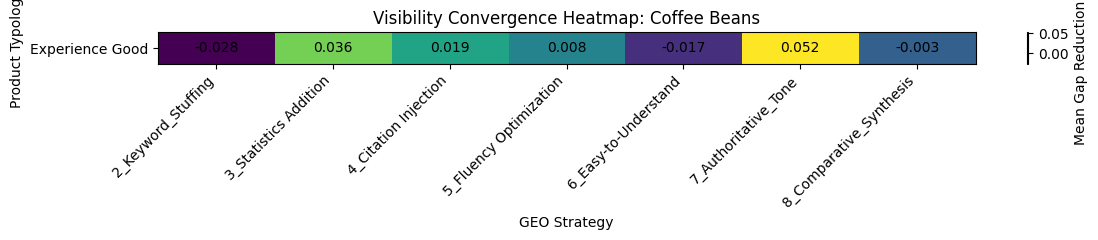

In [54]:
fig, ax = plt.subplots(figsize=(12, 2.5))

data = coffee_heatmap_matrix.values

im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(coffee_heatmap_matrix.columns)))
ax.set_yticks(np.arange(len(coffee_heatmap_matrix.index)))

ax.set_xticklabels(coffee_heatmap_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(coffee_heatmap_matrix.index)

ax.set_title("Visibility Convergence Heatmap: Coffee Beans")
ax.set_xlabel("GEO Strategy")
ax.set_ylabel("Product Typology")

for i in range(len(coffee_heatmap_matrix.index)):
    for j in range(len(coffee_heatmap_matrix.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Mean Gap Reduction in RRS")

plt.tight_layout()
plt.show()